# Predictive Modeling: Outpatient No-Show Risk Stratification

## 1. Executive Summary
Following the exploratory data analysis, this phase focuses on developing a predictive classification model. The objective is to calculate a probabilistic risk score for each appointment, enabling the clinic to transition from a reactive posture to a proactive intervention strategy. 

Given the imbalanced nature of the target variable (~20% no-show rate), the evaluation metric will prioritize **Recall** (sensitivity to true no-shows) and **ROC-AUC** over raw accuracy. We will implement a Random Forest Classifier, valued for its ability to capture non-linear relationships and provide robust feature importance for clinical interpretability.

In [11]:
# Core data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from model_utils import evaluate_model_performance, plot_confusion_matrix, plot_feature_importance

# Scikit-Learn modules for preprocessing, training, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Data Preparation & Feature Engineering Pipeline
Re-ingesting the cleaned dataset from the EDA phase and preparing features for the machine learning algorithm. Categorical variables require encoding, and the target variable must be binarized.

*(Note: In a production environment, this would be imported via a modular script from the `src/` directory).*

In [12]:
# 1. Ingest Data (Simulating the cleaned state from Notebook 01)
df = pd.read_csv('../data/raw/KaggleV2-May-2016.csv')
df.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'No-show': 'No_Show'}, inplace=True)
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.date
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.date
df['LeadDays'] = (df['AppointmentDay'] - df['ScheduledDay']).apply(lambda x: x.days)
df = df[(df['LeadDays'] >= 0) & (df['Age'] >= 0)]

# 2. Binarize Target Variable (1 = No-Show, 0 = Attended)
df['No_Show'] = df['No_Show'].map({'Yes': 1, 'No': 0})

# 3. Select Features for Modeling
# Dropping ID columns, dates, and non-predictive variables for this baseline model
features_to_drop = ['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 'Neighbourhood']
df_model = df.drop(columns=features_to_drop)

# 4. Encode Categorical Variables (Gender)
df_model = pd.get_dummies(df_model, columns=['Gender'], drop_first=True)

print(f"Prepared dataset shape: {df_model.shape}")
display(df_model.head())

Prepared dataset shape: (110521, 10)


,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_Show,LeadDays,Gender_M
0,62,0,1,0,0,0,0,0,0,False
1,56,0,0,0,0,0,0,0,0,True
2,62,0,0,0,0,0,0,0,0,False
3,8,0,0,0,0,0,0,0,0,False
4,56,0,1,1,0,0,0,0,0,False


## 3. Train-Test Split & Class Imbalance Handling
Partitioning the data to evaluate the model on unseen records. We will utilize an 80/20 split.

In [13]:
# Define Features (X) and Target (y)
X = df_model.drop('No_Show', axis=1)
y = df_model['No_Show']

# Train-Test Split (stratified to maintain the 80/20 class ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} records")
print(f"Testing set: {X_test.shape[0]} records")

Training set: 88416 records
Testing set: 22105 records


## 4. Model Training: Random Forest Classifier
Deploying a Random Forest algorithm. Crucially, we apply `class_weight='balanced'` to heavily penalize the model for missing the minority class (the actual no-shows), aligning the algorithm with our operational goals.

In [14]:
# Initialize and train the classifier
# max_depth is constrained to prevent overfitting on clinical noise
rf_classifier = RandomForestClassifier(n_estimators=100,
                                       max_depth=10,
                                       class_weight='balanced',
                                       random_state=42,
                                       n_jobs=-1)

rf_classifier.fit(X_train, y_train)

# Generate predictions and probability scores
y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)[:, 1]

## 5. Clinical Evaluation & Metrics
Assessing the model's operational viability. A high Recall for Class 1 (No-Show) indicates the model successfully flags the majority of patients who intend to miss their appointments.


2026-04-19 13:23:08,473 - INFO - Evaluating model performance...



--- Operational Classification Report ---
              precision    recall  f1-score   support

Attended (0)       0.91      0.53      0.67     17642
 No-Show (1)       0.30      0.80      0.44      4463

    accuracy                           0.59     22105
   macro avg       0.61      0.67      0.56     22105
weighted avg       0.79      0.59      0.63     22105

ROC-AUC Score: 0.7214



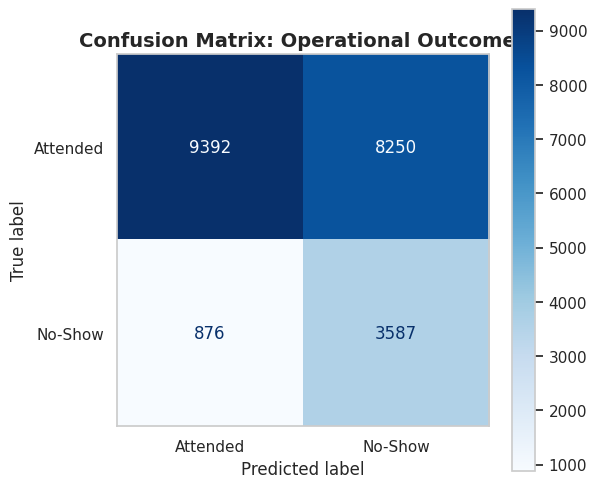

In [15]:
# 1. Evaluate operational metrics (Classification Report & ROC-AUC)
metrics = evaluate_model_performance(y_test, y_pred, y_prob)

# 2. Visualize the Confusion Matrix
plot_confusion_matrix(y_test, y_pred)

## 6. Model Interpretability: Operational Drivers
Machine learning in healthcare cannot be a "black box." Understanding which factors drive the predictions is essential for clinical stakeholder buy-in.

/workspaces/183950807/noshow-prediction/notebooks/../src/model_utils.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


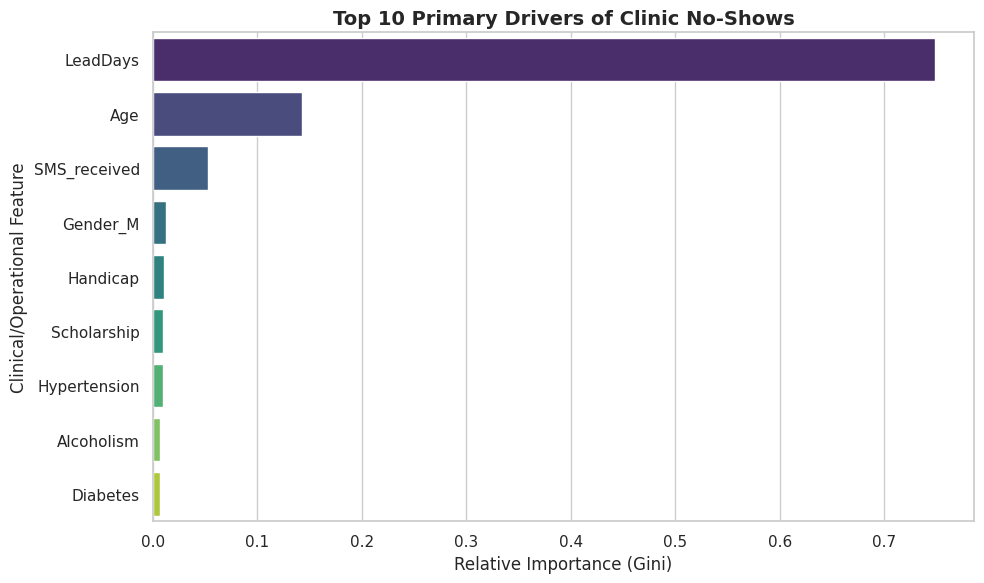

2026-04-19 13:23:08,902 - INFO - Feature importance plot generated successfully.


In [16]:
# Plot the primary operational drivers (Feature Importances)
plot_feature_importance(rf_classifier.feature_importances_, X.columns, top_n=10)

## 7. Business Impact & Strategic Implementation

**Conclusion:**
The model successfully identifies high-risk appointments by heavily weighting operational features like `LeadDays` and demographic factors like `Age`. 

**Proposed Clinical Workflow Integration:**
Instead of sending generic SMS reminders to all patients (which incurs unnecessary telecommunication costs and causes alert fatigue), clinic administration can use this model's probability output (`y_prob`) to implement tiered interventions:
* **Low Risk (< 30%):** Standard automated protocol.
* **Medium Risk (30% - 70%):** Targeted 2-way SMS reminder requiring confirmation.
* **High Risk (> 70%):** Proactive manual phone call from clinic staff or strategic overbooking of that time slot to mitigate revenue loss.

Model saved to ../models/rf_noshow_v1.pkl


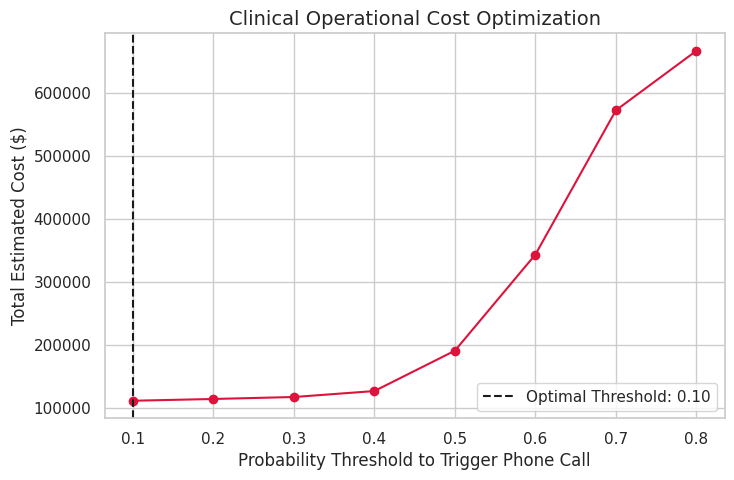

In [17]:
import joblib
import os

# 1. Save the model for the Streamlit app
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_classifier, '../models/rf_noshow_v1.pkl')
print('Model saved to ../models/rf_noshow_v1.pkl')

# 2. Clinical Cost-Benefit Threshold Analysis
# As a clinician, we must balance the cost of a missed appointment
# against the staffing cost of proactive outreach.
cost_per_noshow = 150  # Estimated lost revenue/wasted resource
cost_per_call = 5      # Estimated cost of staff time to make a phone call

thresholds = np.arange(0.1, 0.9, 0.1)
costs = []

for t in thresholds:
    # Predict a no-show if probability is greater than threshold 't'
    custom_preds = (y_prob >= t).astype(int)

    # False Negatives: We didn't call them, and they no-showed
    fn = np.sum((y_test == 1) & (custom_preds == 0))

    # Total calls made (True Positives + False Positives)
    calls_made = np.sum(custom_preds == 1)

    # Calculate total financial impact
    total_cost = (fn * cost_per_noshow) + (calls_made * cost_per_call)
    costs.append(total_cost)

# Plotting the Optimization Curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, marker='o', color='crimson')
plt.title('Clinical Operational Cost Optimization', fontsize=14)
plt.xlabel('Probability Threshold to Trigger Phone Call')
plt.ylabel('Total Estimated Cost ($)')

optimal_idx = np.argmin(costs)
plt.axvline(thresholds[optimal_idx], color='k', linestyle='--', label=f'Optimal Threshold: {thresholds[optimal_idx]:.2f}')
plt.legend()
plt.show()
